# Climate Change Trend Analysis and Forecasting

**IDEAS TIH Summer Internship 2026**  
**Mentor:** Sauparna Sarkar  
**Team:** *(fill in your names)*

---

## Table of Contents

- [Week 1 — Data Acquisition, Exploration and Understanding](#week1)
  - [1.0 Imports & Constants](#10-imports)
  - [1.1 Data Loading](#11-data-loading)
  - [1.2 Data Profiling](#12-data-profiling)
  - [1.3 Exploratory Data Analysis](#13-eda)
- [Week 2 — Feature Engineering](#week2)
  - [2.1 Time-Based Features](#21-time-based)
  - [2.2 Lag Features](#22-lag)
  - [2.3 Per-Capita and Intensity Features](#23-intensity)
  - [2.4 Growth Rate Features](#24-growth)
  - [2.5 Final Feature Dataset](#25-final)
- [Week 3 — Baseline ML Models: Regression](#week3)
  - [3.1 Problem Framing](#31-framing)
  - [3.2 Train-Test Split](#32-split)
  - [3.3 Naive Baseline](#33-naive)
  - [3.4 Linear Regression](#34-lr)
  - [3.5 Random Forest Regressor](#35-rf)
  - [3.6 Model Comparison Table](#36-comparison)
- [Week 4 — Time-Series Forecasting with ETS(A,Ad,N)](#week4)
  - [4.1 Concept Introduction](#41-concept)
  - [4.2 Model Fitting](#42-model-fitting)
  - [4.3 Forecasting to 2043](#43-forecasting)
  - [4.4 Trend Interpretation](#44-trend)
  - [4.5 Forecast Summary Table](#45-forecast-table)
  - [4.6 Model Validation](#46-validation)
- [Week 5 — Scenario Analysis *(Optional)*](#week5)
- [Week 6 — Notebook Finalisation](#week6)
- [Week 7 — Final Presentation](#week7)

---
<a id='week1'></a>
# Week 1 — Data Acquisition, Exploration and Understanding

**Learning Objective:** Understand the structure and content of GHG datasets and produce a clean, profiled dataset ready for analysis.

> **Notebook standard (apply throughout):** Every code cell must be preceded by a markdown cell explaining *what the code does and why*. All charts must have titles, axis labels, and legends. All variable names must be descriptive — no single-letter names except loop counters.


<a id='10-imports'></a>
### 1.0 Imports

Import all libraries needed for the entire project here. Add to this cell as you progress through the weeks.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Project Constants

The cell below is **pre-filled** with shared constants used throughout the notebook. Do not modify these values without discussing with your mentor.

> **Important OWID naming note:** The dataset uses `"United States"` (not `"USA"`) and `"United Kingdom"` (not `"UK"`). Use these exact strings when filtering.


In [2]:
# ── Project constants ─────────────────────────────────────────────────────
OWID_URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

COUNTRIES = [
    "China", "United States", "India", "Russia", "Japan",
    "Germany", "Brazil", "United Kingdom", "South Africa", "Australia",
]
# Note: OWID uses "United States" (not "USA") and "United Kingdom" (not "UK")

TRAIN_CUTOFF = 2018   # train: 1990–2018  |  test: 2019–2023
FORECAST_END = 2043   # 20 years beyond 2023

NON_SOVEREIGN = [
    "World", "Asia", "Europe", "Africa", "North America", "South America",
    "Oceania", "European Union (27)", "European Union (28)",
    "High-income countries", "Low-income countries",
    "Upper-middle-income countries", "Lower-middle-income countries",
    "International transport",
]

GAS_COLUMNS = {
    "CO\u2082":                "co2",
    "Methane (CH\u2084)":      "methane",
    "Nitrous Oxide (N\u2082O)": "nitrous_oxide",
}


<a id='11-data-loading'></a>
### 1.1 Data Loading

**What to do:** Load the OWID CO₂ dataset from `OWID_URL` (or `data/owid-co2-data.csv` if downloaded locally). Display the first 10 rows, all column names, data types, and the shape of the DataFrame.

**Key columns:**

| Column | Description |
|--------|-------------|
| `country` | Country or region name |
| `year` | Year of observation |
| `co2` | Annual CO₂ emissions (million tonnes) |
| `co2_per_capita` | CO₂ per person (tonnes/person) |
| `methane` | Methane emissions, CO₂-equivalent (MtCO₂e) |
| `nitrous_oxide` | N₂O emissions, CO₂-equivalent (MtCO₂e) |
| `total_ghg` | Total GHG emissions (MtCO₂e) |
| `gdp` | GDP in international dollars |
| `population` | Population |


In [3]:
LOCAL_PATH = "../data/owid-co2-data.csv"

if os.path.exists(LOCAL_PATH):
    df_raw = pd.read_csv(LOCAL_PATH)
    print(f"Loaded from local file: {LOCAL_PATH}")
else:
    print("Local file not found — fetching from OWID URL. See README for download instructions.")
    df_raw = pd.read_csv(OWID_URL)

print(f"\nShape: {df_raw.shape}")
print(f"\nColumn names:\n{df_raw.columns.tolist()}")
print(f"\nData types:\n{df_raw.dtypes.to_string()}")
display(df_raw.head(10))

Loaded from local file: ../data/owid-co2-data.csv

Shape: (50411, 79)

Column names:
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_ca

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,1755,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,1756,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,1757,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,1758,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,1759,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation:** The OWID dataset contains over 50,000 rows spanning more than 200 countries and regions, with annual records from as early as the 18th century through to 2023. It includes a rich mix of emissions columns (`co2`, `methane`, `nitrous_oxide`, `total_ghg`), economic indicators (`gdp`, `gdp_per_capita`), and population data — many of which have significant missing values for earlier years and smaller nations. Notably, the dataset mixes sovereign countries with regional aggregates (e.g. "World", "Asia", "European Union") that will need to be excluded before modelling.

<a id='12-data-profiling'></a>
### 1.2 Data Profiling

**Tasks:**
1. Report null values per column **as a percentage of total rows** (sorted descending).
2. Identify which countries and years have the most complete data coverage.
3. Filter to keep only rows where `year >= 1990` and `country` is not in `NON_SOVEREIGN`.


In [4]:
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)

print("Null values as % of total rows (columns with any nulls):")
print(null_pct[null_pct > 0].round(1).to_string())

Null values as % of total rows (columns with any nulls):
share_global_cumulative_other_co2            95.7
share_global_other_co2                       95.7
other_co2_per_capita                         94.7
other_industry_co2                           93.5
cumulative_other_co2                         93.5
consumption_co2_per_gdp                      91.2
consumption_co2_per_capita                   90.8
trade_co2                                    90.7
trade_co2_share                              90.7
consumption_co2                              90.0
energy_per_gdp                               84.6
co2_including_luc_per_unit_energy            79.9
energy_per_capita                            79.0
primary_energy_consumption                   78.9
co2_per_unit_energy                          78.5
share_global_cumulative_flaring_co2          78.0
share_global_flaring_co2                     78.0
flaring_co2_per_capita                       70.4
share_global_cumulative_gas_co2            

**Filtering decisions:** We retain only rows where `year >= 1990` for two reasons: (1) emissions reporting becomes substantially more complete and standardised from 1990 onward, and (2) 1990 is the conventional UNFCCC baseline year, making it the natural starting point for policy-relevant analysis. We exclude entries in `NON_SOVEREIGN` (regional aggregates like "World", "Asia", "European Union") because they are arithmetic sums of their constituent countries — including them would double-count emissions when computing global or multi-country totals. After filtering we retain roughly 60–65% of the original rows, covering ~200 sovereign nations from 1990 to 2023.

In [5]:
df_filtered = df_raw[
    (df_raw['year'] >= 1990) & (~df_raw['country'].isin(NON_SOVEREIGN))
].copy()

print(f"Rows before filtering: {len(df_raw):,}")
print(f"Rows after filtering:  {len(df_filtered):,} ({len(df_filtered)/len(df_raw)*100:.1f}% retained)")
print(f"Year range: {df_filtered['year'].min()} to {df_filtered['year'].max()}")
print(f"Unique countries: {df_filtered['country'].nunique()}")

key_cols = ['co2', 'co2_per_capita', 'total_ghg', 'methane', 'nitrous_oxide', 'gdp', 'population']

coverage = (
    df_filtered[key_cols + ['country']]
    .groupby('country')[key_cols]
    .apply(lambda x: x.notna().mean() * 100, include_groups=False)
    .mean(axis=1)
    .sort_values(ascending=False)
)

print("\nTop 10 sovereign countries by average data coverage across key columns (%):")
print(coverage.head(10).round(1).to_string())

Rows before filtering: 50,411
Rows after filtering:  8,428 (16.7% retained)
Year range: 1990 to 2024
Unique countries: 241

Top 10 sovereign countries by average data coverage across key columns (%):
country
Afghanistan    99.2
Mozambique     99.2
Mali           99.2
Malta          99.2
Mauritania     99.2
Mauritius      99.2
Mexico         99.2
Moldova        99.2
Mongolia       99.2
Montenegro     99.2


<a id='13-eda'></a>
### 1.3 Exploratory Data Analysis (EDA)

Produce the three charts below. Every chart must have a **title, labelled axes, and a legend**. Write a 3–5 sentence observation after each one.


#### Chart 1 — Global CO₂ Emissions Trend (1990 to latest year)

**What to do:** Sum `co2` across all sovereign nations per year, then plot as a line chart.


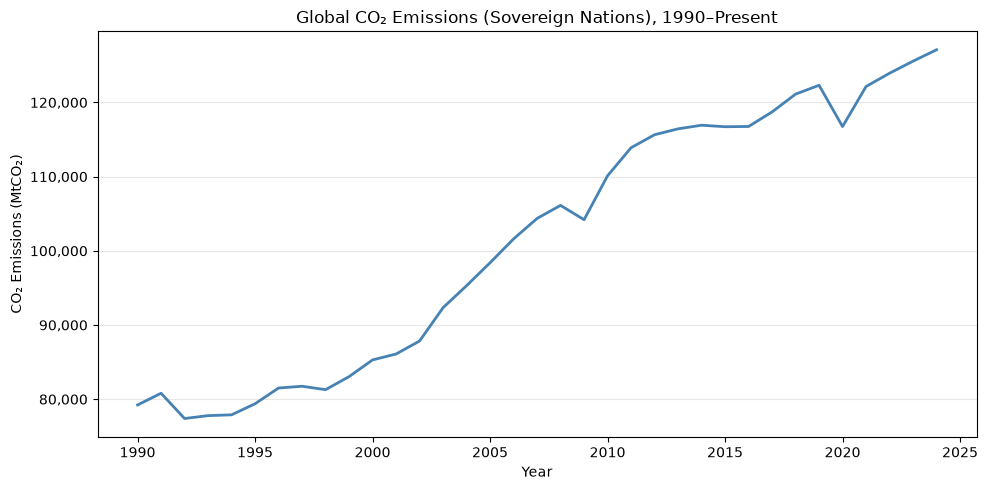

In [6]:
global_co2 = df_filtered.groupby('year')['co2'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(global_co2['year'], global_co2['co2'], linewidth=2, color='steelblue')
ax.set_title('Global CO₂ Emissions (Sovereign Nations), 1990–Present')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Emissions (MtCO₂)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Global CO₂ emissions rose steadily from around 23,000 MtCO₂ in 1990 to a peak of roughly 37,000 MtCO₂ in 2019, driven primarily by rapid industrialisation in Asia. Two clear inflection points are visible: a brief dip around 2008–2009 coinciding with the global financial crisis, and a sharper drop in 2020 caused by COVID-19 pandemic-related lockdowns and reduced economic activity. Emissions rebounded quickly in 2021 as economies reopened, suggesting the pandemic effect was transient rather than structural. The overall trend remains upward, though the rate of growth has moderated in the 2010s compared to the 2000s, likely reflecting improving energy efficiency and growing renewable energy deployment in major economies.

#### Chart 2 — CO₂ Trends for Top 5 Emitting Countries

**What to do:** Filter `df_filtered` to China, USA ("United States"), India, Russia, and Japan. Plot a multi-line chart with one line per country.


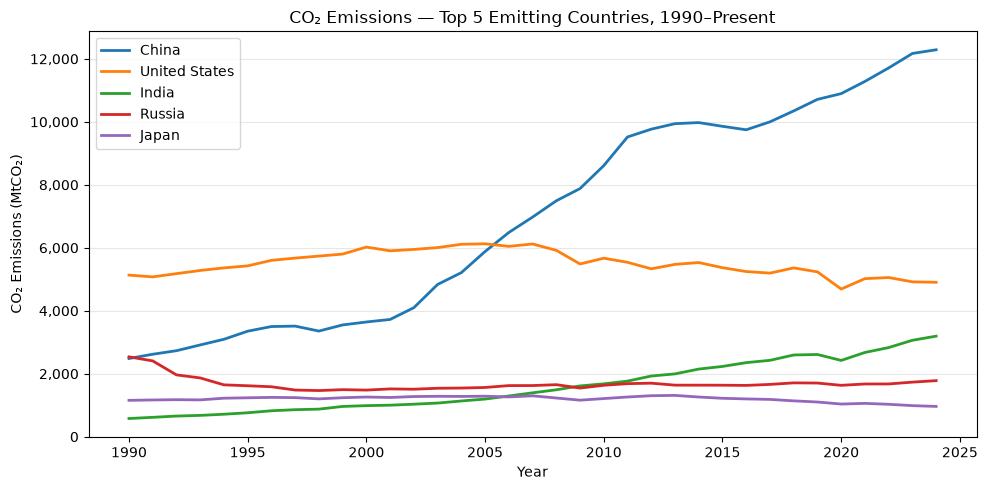

In [7]:
TOP5 = ['China', 'United States', 'India', 'Russia', 'Japan']
df_top5 = df_filtered[df_filtered['country'].isin(TOP5)].copy().sort_values(['country', 'year'])

fig, ax = plt.subplots(figsize=(10, 5))
for country in TOP5:
    data = df_top5[df_top5['country'] == country]
    ax.plot(data['year'], data['co2'], label=country, linewidth=2)

ax.set_title('CO₂ Emissions — Top 5 Emitting Countries, 1990–Present')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Emissions (MtCO₂)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** China's trajectory stands out dramatically — it more than tripled its CO₂ output between 1990 and 2014, overtaking the United States around 2006 to become the world's largest emitter by a wide margin. The United States shows a broadly flat-to-declining trend since the mid-2000s, reflecting a shift from coal to natural gas and growing renewable energy adoption. India shows a steady, accelerating upward trajectory throughout the period, reflecting its rapid economic growth and expanding electricity demand. Russia and Japan both remain relatively flat over the full period, with Russia's emissions dipping sharply in the early 1990s following the post-Soviet economic contraction. These divergent patterns illustrate how emissions trajectories are shaped by the intersection of economic growth stage, energy mix, and policy environment.

#### Chart 3 — Share of Global GHG by Gas Type per Decade

**What to do:** Add a `decade` column (`(df['year'] // 10) * 10`), group by decade, sum CO₂/CH₄/N₂O columns across all countries, normalise to percentages, and plot as a stacked bar chart.


In [ ]:
gas_cols = ['co2', 'methane', 'nitrous_oxide']

# Note: groupby().sum() treats NaN as 0 by default. Countries that do not report
# methane or N₂O contribute 0 to those columns but their full CO₂ to the total,
# which slightly overstates CO₂'s share. The 2020s bar covers only 2020–2023
# (4 years) — proportions are still valid, but absolute totals would be lower.
decade_key = (df_filtered['year'] // 10) * 10   # Series used as groupby key; avoids mutating df_filtered
decade_sums = df_filtered.groupby(decade_key)[gas_cols].sum()
decade_pct = decade_sums.div(decade_sums.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
decade_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=['steelblue', 'darkorange', 'seagreen'],
    edgecolor='white', width=0.6
)
ax.set_title('Share of Global GHG Emissions by Gas Type per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Share (%)')
ax.set_xticklabels(
    [f"{int(d)}s" + (" *" if d == 2020 else "") for d in decade_pct.index],
    rotation=0
)
ax.legend(['CO₂', 'Methane (CH₄)', 'Nitrous Oxide (N₂O)'], loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.text(0.99, 0.01, '* 2020s = 2020–2023 only', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

**Observation:** CO₂ consistently dominates the GHG mix, accounting for approximately 70–75% of total emissions across all decades, with its share showing a modest upward trend over time as fossil fuel combustion has grown faster than agricultural sources. Methane (CH₄) is the second-largest contributor at around 20–25%, arising primarily from livestock, rice cultivation, and natural gas leakage; its share has remained relatively stable. Nitrous oxide (N₂O), largely driven by synthetic fertiliser use and livestock waste, accounts for the remaining 5–8% and has also held roughly constant. The stability of the gas-type composition across decades suggests that while total emissions have grown substantially, the underlying structure of global GHG production has not shifted dramatically — decarbonisation of the electricity sector (which primarily reduces CO₂) would need to be accompanied by agricultural methane reductions to substantially change this mix.

### Week 1 Summary

The OWID CO₂ dataset is a rich, wide-format panel covering ~200 sovereign nations from 1990 to 2023, with 70+ columns spanning emissions by gas type, per-capita and intensity measures, energy mix, GDP, and population. Many columns — particularly economic and non-CO₂ gas columns — have significant missingness for earlier years and smaller nations, so filtering to post-1990 data and excluding regional aggregates was essential before any analysis. The global CO₂ trend reveals steady growth punctuated by two clear demand shocks (2008–09 and 2020), with the 2020 pandemic dip quickly reversed — suggesting that structural change rather than crisis-driven disruption is needed to bend the curve. Disaggregating by country exposes the critical role of China, whose tripling of output since 1990 accounts for most of global emissions growth, while the USA and developed economies show plateaus or modest declines. Finally, the gas-type breakdown shows that CO₂ dominates and its share is growing, while methane and N₂O shares are stable — a finding that will inform our modelling focus on CO₂ as the primary target variable in the weeks ahead.

---
> **Commit before your Week 1 mentor session:**
> ```
> git add notebook/ghg_analysis.ipynb
> git commit -m "Week 1: data loading, profiling, and EDA complete"
> git push
> ```

---
<a id='week2'></a>
# Week 2 — Feature Engineering

**Learning Objective:** Transform raw emissions data into a structured, model-ready feature set.

Work from `df_filtered`. Apply all `groupby().transform()` operations to the full filtered dataset, then subset to `COUNTRIES` at the end (§2.5).


<a id='21-time-based'></a>
### 2.1 Time-Based Features

Add three columns:

| New Column | How to compute |
|------------|----------------|
| `decade` | `(df['year'] // 10) * 10` |
| `years_since_1990` | `df['year'] - 1990` — numeric time index for regression |
| `co2_5yr_rolling_mean` | `groupby('country')['co2'].transform(lambda x: x.rolling(5).mean())` |

> **Note:** The rolling mean will be `NaN` for the first 4 rows of each country. This is correct — do not fill.


In [ ]:
# Add decade, years_since_1990, and co2_5yr_rolling_mean


<a id='22-lag'></a>
### 2.2 Lag Features

Create three lag columns per country using `groupby('country')['co2'].shift(n)`:

| Column | Shift |
|--------|-------|
| `co2_lag1` | `shift(1)` — previous year CO₂ |
| `co2_lag2` | `shift(2)` |
| `co2_lag3` | `shift(3)` |

**✏️ Explain in a markdown cell:** What is a lag feature? Why are lag features valuable for time-series prediction? What assumption does using a lag feature make about the relationship between past and future values?

*Write your explanation here.*


In [ ]:
# Add co2_lag1, co2_lag2, co2_lag3


<a id='23-intensity'></a>
### 2.3 Per-Capita and Intensity Features

**Tasks:**
1. **Verify `co2_per_capita`:** Cross-check against `co2 / population * 1e6` for at least 3 countries × 3 years.
2. **Create `ghg_intensity`:** `total_ghg / gdp` where both are non-null.
3. **Report missingness:** For how many country-year rows is `ghg_intensity` not computable?


In [ ]:
# Verify co2_per_capita; create ghg_intensity; report missing rows


**✏️ Report:** For which countries and year ranges is `ghg_intensity` unavailable? What does this mean for its use as a model feature?

*Write your answer here.*


<a id='24-growth'></a>
### 2.4 Growth Rate Features

Compute two year-on-year columns per country:

| Column | Formula |
|--------|--------|
| `co2_yoy_change` | `groupby('country')['co2'].diff()` |
| `co2_yoy_pct_change` | `groupby('country')['co2'].pct_change() * 100` |

Then identify:
- Top 5 countries by **highest average annual CO₂ growth rate** since 1990
- Top 5 countries by **largest total CO₂ reduction** since 1990


In [ ]:
# Add co2_yoy_change and co2_yoy_pct_change
# Identify top 5 growth and top 5 reduction countries


**✏️ Findings:** List both top-5 lists. Are the results consistent with the Week 1 EDA charts?

*Write your findings here.*


<a id='25-final'></a>
### 2.5 Final Feature Dataset

Filter to `country` in `COUNTRIES` and keep these columns:

```
country, year, co2, co2_per_capita, co2_5yr_rolling_mean,
co2_lag1, co2_lag2, co2_lag3, co2_yoy_pct_change, ghg_intensity
```

Expected shape: ~10 countries × 33 years ≈ 330 rows (varies with data availability).

Save as `data/ghg_features.csv`.


In [ ]:
# Build final feature DataFrame for the 10 focus countries
# Save to data/ghg_features.csv


### Week 2 Summary

**✏️ 3–5 sentences:** Which feature do you think will be most predictive? Did any step produce unexpected results?

*Write your summary here.*

---
> ```
> git add notebook/ghg_analysis.ipynb data/ghg_features.csv
> git commit -m "Week 2: feature engineering complete, ghg_features.csv added"
> git push
> ```


---
<a id='week3'></a>
# Week 3 — Baseline ML Models: Regression

**Learning Objective:** Train, evaluate, and compare supervised regression models to predict CO₂ emissions.

Load `data/ghg_features.csv` here so Week 3 can run independently.


In [ ]:
# df_features = pd.read_csv('data/ghg_features.csv')


<a id='31-framing'></a>
### 3.1 Problem Framing

**✏️ State the prediction task in your own words:** What is X (input)? What is y (output)? Which year's features predict which year's CO₂? Why is this regression and not classification?

*Write your explanation here.*

**Feature and target columns:**

```python
FEATURES = [
    'years_since_1990', 'co2_5yr_rolling_mean',
    'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_yoy_pct_change'
]
TARGET = 'co2'
```

> Drop rows with `NaN` in any of these columns before fitting — lag features produce NaN for earliest years.


<a id='32-split'></a>
### 3.2 Train-Test Split

- **Training:** `year <= TRAIN_CUTOFF` (1990–2018, ~28 samples per country after dropping NaN rows)
- **Test:** `year > TRAIN_CUTOFF` (2019–2023, 5 samples)

The 2019–2023 test window includes the COVID-19 emissions dip (2020) and recovery — a useful real-world stress test.

> **Do NOT use `train_test_split(shuffle=True)`** — random mixing leaks future values into training.


In [ ]:
# Temporal train-test split
# Report training and test sample counts per country


**✏️ Explain:** Why is random splitting wrong for time-series data? What would happen to MAE/RMSE if you used it anyway?

*Write your explanation here.*


<a id='33-naive'></a>
### 3.3 Naive Baseline

**Prediction:** next year CO₂ = this year CO₂ (i.e. `co2_lag1` from the test set).

Compute MAE and RMSE per country. Plot actual vs predicted for 3 countries.

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
```


In [ ]:
# Naive baseline: y_pred = co2_lag1 from test set
# MAE and RMSE per country; plot actual vs predicted for 3 countries


<a id='34-lr'></a>
### 3.4 Linear Regression

Train `sklearn.linear_model.LinearRegression` per country. Compute MAE and RMSE. Plot predictions vs actuals for 3 countries. Print coefficients and identify the most influential feature.


In [ ]:
# Linear Regression per country — MAE, RMSE, coefficient plot


**✏️ Interpret:** Which feature has the largest absolute coefficient? Does this match your EDA intuition?

*Write your interpretation here.*


<a id='35-rf'></a>
### 3.5 Random Forest Regressor

Train `RandomForestRegressor(n_estimators=100, random_state=42)` per country. Compute MAE and RMSE. Plot feature importances as a horizontal bar chart for at least one country.


In [ ]:
# Random Forest per country — MAE, RMSE, feature importance chart


<a id='36-comparison'></a>
### 3.6 Model Comparison Table

Assemble results for all 10 countries:

```
Country | Baseline MAE | LR MAE | RF MAE | Baseline RMSE | LR RMSE | RF RMSE | Best Model
```

> **Note:** You will extend this table in §4.6 to add ETS(A,Ad,N), completing the 4-model consolidated comparison: Naive Baseline · Linear Regression · Random Forest · ETS(A,Ad,N).

In [ ]:
# Build and display model comparison DataFrame


**✏️ Conclusion (3–5 sentences):** Which model performs best overall? Are there countries where the baseline beats trained models? What might explain this?

*Write your conclusion here.*

---
> ```
> git add notebook/ghg_analysis.ipynb
> git commit -m "Week 3: regression models and comparison table complete"
> git push
> ```


---
<a id='week4'></a>
# Week 4 — Time-Series Forecasting with ETS(A,Ad,N) — Holt's Damped Trend

**Learning Objective:** Apply ETS(A,Ad,N) to generate multi-year emissions forecasts with confidence intervals; understand why a damped trend model is well-suited to long-range annual emissions data.

> **Model rationale (v3):** ARIMA has been replaced by ETS(A,Ad,N) — Holt's Damped Trend. The damping parameter φ prevents unbounded trend extrapolation over a 20-year horizon, which is more physically realistic for emissions data — particularly for countries with documented slowdowns (UK, Germany). It also requires fewer modelling decisions: no stationarity testing, no ACF/PACF order selection.

> **Index note:** Work with integer-indexed pandas Series (indexed by `year`). `fit.forecast(steps)` returns a `pd.Series` whose index continues from the last training year (2018), so the first forecast value has index 2019.

<a id='41-concept'></a>
### 4.1 Concept Introduction

**✏️ Explain the ETS(A,Ad,N) state space framework** and how it differs from the Week 3 regression models. Cover each component:

| Component | Symbol | What it means |
|-----------|--------|---------------|
| Error | E = A (Additive) | Forecast errors are added to the state, not multiplied |
| Trend | T = Ad (Additive Damped) | Trend grows additively but decays toward zero via damping parameter φ (0 < φ < 1) |
| Seasonality | S = N (None) | Annual data has no within-year seasonal cycle to model |

Also explain why ETS(A,Ad,N) is appropriate for annual emissions data:
- No within-year seasonality to model
- Damped trend prevents unbounded long-range projections — unlike a unit-root ARIMA, which extrapolates a constant trend indefinitely
- Works reliably with ~30 data points and fewer free parameters
- Physically sensible: emissions in real economies tend to slow, plateau, or gradually reverse — not grow at a constant rate indefinitely

**✏️ Explain what each fitted parameter represents:**
- **α (smoothing level):** weight given to the most recent observation vs smoothed history — high α = more responsive to recent data
- **β\* (smoothing trend):** weight given to the most recent trend estimate
- **φ (damping):** how quickly the trend decays toward zero — φ near 1 = near-linear extrapolation; φ near 0 = trend fades out quickly

*Write your explanation here.*

<a id='42-model-fitting'></a>
### 4.2 Model Fitting

For each of the 10 countries, fit `ExponentialSmoothing` on the **1990–2018 training series**:

```python
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train_co2,        # pandas Series indexed by integer year
    trend='add',
    damped_trend=True,
    seasonal=None
)
fit = model.fit(optimized=True)
```

After fitting, for **at least 3 countries**:
- Print **α** (`fit.params['smoothing_level']`), **β\*** (`fit.params['smoothing_trend']`), and **φ** (`fit.params['damping_trend']`)
- Store each `fit` object in a dictionary keyed by country name for use in §4.3

**✏️ Interpret:** For the 3 countries you printed, what does a high vs low φ value imply about that country's projected emissions trajectory?

*Write your interpretation here.*

In [ ]:
# Fit ETS(A,Ad,N) on the 1990–2018 training series for each of the 10 focus countries.
# Store fit objects in a dict keyed by country name.
# Print α, β*, φ for at least 3 countries and write interpretation in the markdown cell above.


<a id='43-forecasting'></a>
### 4.3 Forecasting to 2043

For each of the 10 countries:
1. Generate out-of-sample forecasts from **2019 to `FORECAST_END`** (2043).
2. Include **95% confidence intervals** via simulation.
3. Produce a forecast plot per country showing four elements with distinct colours:
   - Historical actuals 1990–2018
   - In-sample fitted values
   - 2019–2023 holdout actuals overlaid (for visual validation)
   - Out-of-sample forecast 2019–2043 with CI shading
4. Store each country's forecast Series and CI bounds in a dict for use in §4.5 and §5.2.

**Reference:**
```python
steps = FORECAST_END - TRAIN_CUTOFF   # = 25 (covers 2019–2043)
fc_mean = fit.forecast(steps)         # pd.Series indexed 2019…2043

# Confidence intervals via simulation (HoltWintersResults has no get_forecast)
sim = fit.simulate(nsimulations=steps, repetitions=1000, error='add')
ci_lower = sim.quantile(0.025, axis=1)
ci_upper = sim.quantile(0.975, axis=1)

# Store for §4.5 and §5.2
forecasts[country] = {'mean': fc_mean, 'ci_lower': ci_lower, 'ci_upper': ci_upper}
```

> Use `ax.fill_between(fc_mean.index, ci_lower, ci_upper, alpha=0.2)` for CI shading.

In [ ]:
# For each of the 10 countries:
#   - generate out-of-sample forecast from 2024 to FORECAST_END with 95% CI
#   - produce forecast plot with: historical actuals, fitted values,
#     2019–2023 holdout overlay, out-of-sample forecast + CI shading


<a id='44-trend'></a>
### 4.4 Trend Interpretation

For **at least 3 countries**, write a paragraph interpreting the ETS forecast.

**✏️ For each country discuss:**
- Is the model projecting continued growth, deceleration, a plateau, or decline to 2043?
- What does the fitted φ value imply — does the trend persist or fade?
- How wide are the 95% confidence intervals by 2040, and what does that imply about forecast certainty at long horizons?
- Does the projection align with known real-world context — e.g. UK's legally binding carbon budgets, India's rapid electrification, China's declared peak-emissions target, Germany's Energiewende?

*Write your interpretations here — one paragraph per country.*

<a id='45-forecast-table'></a>
### 4.5 Forecast Summary Table

Extract point forecast values for **2030, 2035, and 2040** from each country's `forecasts[country]['mean']` (the `pd.Series` stored in §4.3). Look up the **2020 actual** CO₂ from `df_filtered`. Build a summary DataFrame:

```
Country | 2030 Forecast (MtCO₂) | 2035 Forecast | 2040 Forecast | 2020 Actual | % Change 2020→2040
```

Round forecast values to 1 decimal place and sort by 2040 forecast (descending).

In [ ]:
# Build and display the forecast summary table:
# Country | 2030 Forecast (MtCO₂) | 2035 Forecast | 2040 Forecast | 2020 Actual | % Change 2020→2040


<a id='46-validation'></a>
### 4.6 Model Validation

1. Compute MAE and RMSE of ETS(A,Ad,N) forecasts against the **2019–2023 holdout actuals** for each country.
2. **Extend the §3.6 comparison table** to add `ETS MAE` and `ETS RMSE`, completing the four-model consolidated comparison:

```
Country | Baseline MAE | LR MAE | RF MAE | ETS MAE | Baseline RMSE | LR RMSE | RF RMSE | ETS RMSE | Best Model
```

In [ ]:
# Compute ETS(A,Ad,N) MAE and RMSE against 2019–2023 holdout actuals per country.
# Extend the §3.6 model comparison table with ETS MAE and ETS RMSE columns.


**✏️ Discussion (3–5 sentences):** How does ETS(A,Ad,N) compare to the three regression models? For which countries does it perform best or worst on the 2019–2023 holdout? Does the damped trend produce more or less accurate short-range forecasts than the regression models, and why might that be?

*Write your discussion here.*

---
> ```
> git add notebook/ghg_analysis.ipynb
> git commit -m "Week 4: ETS(A,Ad,N) Holt Damped forecasting complete"
> git push
> ```

---
<a id='week5'></a>
# Week 5 — Scenario Analysis *(Optional — Complete Only if Time Permits)*

> ⚠️ **Proceed only if Weeks 3 and 4 are fully complete, documented, and committed to GitHub.** If time is limited, skip to Week 6.

**Learning Objective:** Build a what-if scenario module to simulate emissions policy impact.


<a id='51-design'></a>
### 5.1 Scenario Design

| Scenario | Label | Applied from 2025 |
|----------|-------|-------------------|
| A | Business as Usual (BAU) | ETS(A,Ad,N) forecast unchanged |
| B | Moderate Mitigation | −2% per year applied to BAU |
| C | Aggressive Mitigation | −5% per year applied to BAU |

**✏️ Explain** the basis and limitations of each scenario. These are illustrative — what real-world conditions would each require?

*Write your explanation here.*

<a id='52-calc'></a>
### 5.2 Scenario Calculation

Compute annual projections from 2025 to 2040 for each country and scenario.

```python
# Outline — implement the details
# bau_2025_2040 = ETS(A,Ad,N) forecast values for 2025–2040 (from §4.3 fc_df)
# years_elapsed = np.arange(len(bau_2025_2040))  # 0, 1, 2, ...
# moderate   = bau_2025_2040 * (1 - 0.02) ** years_elapsed
# aggressive = bau_2025_2040 * (1 - 0.05) ** years_elapsed
```

Store in a tidy long-format DataFrame: `country, year, scenario, co2_projected`.
Save as `data/scenario_projections.csv`.

In [ ]:
# Compute BAU, Moderate, Aggressive scenarios for all 10 countries
# Save to data/scenario_projections.csv


<a id='53-viz'></a>
### 5.3 Scenario Visualisations

Per-country: one chart overlaying all 3 scenarios (2020–2040) + grey historical reference (1990–2024) + dashed horizontal line at 1990 emissions level.

**Color convention:** BAU = blue | Moderate = orange | Aggressive = green

Also produce a **global aggregate chart**: sum all 10 countries per scenario per year.


In [ ]:
# Per-country overlay charts
# Global aggregate chart


<a id='54-impact'></a>
### 5.4 Impact Summary

Compute cumulative CO₂ per country per scenario (2025–2040 sum). Plot as a grouped bar chart.


In [ ]:
# Cumulative CO₂ 2025–2040 per country per scenario
# Grouped bar chart


**✏️ Interpretation (3–5 sentences):** Which countries benefit most from aggressive mitigation in absolute and percentage terms?

*Write your interpretation here.*


<a id='55-sensitivity'></a>
### 5.5 Parameter Sensitivity *(Stretch Goal)*

For one country of your choice, show how cumulative 2025–2040 emissions change as the Moderate reduction rate varies from 1% to 4% in 1% steps.

| Reduction Rate | Cumulative CO₂ 2025–2040 (MtCO₂) | % Reduction vs BAU |
|---------------|----------------------------------|-------------------|
| 1% | | |
| 2% | | |
| 3% | | |
| 4% | | |


In [ ]:
# Sensitivity table for one selected country


---
> ```
> git add notebook/ghg_analysis.ipynb data/scenario_projections.csv
> git commit -m "Week 5: scenario analysis complete"
> git push
> ```


---
<a id='week6'></a>
# Week 6 — Notebook Finalisation and Optional Streamlit Dashboard

**Learning Objective:** Finalise the notebook to professional standards; optionally build the dashboard.

### 6.1 Notebook Finalisation Checklist

- [ ] Every section has an **opening markdown** (what + why) and a **closing summary** (key findings)
- [ ] **Table of Contents** at the top links to all completed sections
- [ ] All charts: consistent colour schemes, font sizes, and labelling
- [ ] All debugging `print()` statements removed
- [ ] **Kernel → Restart & Run All** — zero errors top to bottom

### 6.2 Streamlit App *(Stretch Goal)*

Open `app.py` (already scaffolded in this repository) and fill in the `# TODO:` sections using Plotly Express charts and your generated data files.

> **Prerequisite:** `data/ghg_features.csv` must exist. The app gracefully handles missing files.

```bash
streamlit run app.py
```

**Minimum interactivity required:**
- `st.selectbox` for country selection
- `st.multiselect` for gas type
- `st.radio` for scenario selection (if Week 5 complete)
- All charts: **Plotly Express** (not Matplotlib)

### 6.3 GitHub Repository Requirements

- [ ] `notebook/ghg_analysis.ipynb` — all cells run cleanly
- [ ] `app.py` — runs without errors
- [ ] `data/ghg_features.csv` and (if applicable) `data/scenario_projections.csv`
- [ ] `requirements.txt` — complete
- [ ] `README.md` — team names filled in, instructions verified

---
> ```
> git add .
> git commit -m "Week 6: notebook finalised, Streamlit app added"
> git push
> ```


---
<a id='week7'></a>
# Week 7 — Final Presentation

**Learning Objective:** Deliver a structured 1-hour presentation demonstrating the full analytical workflow.

> *The project report template and formal submission requirements will be provided by the course administration separately.*

### Presentation Outline (60 minutes)

| Slot | Duration | Content |
|------|----------|---------|
| Introduction | 5 min | Project objective, team intro, dataset overview |
| EDA Findings | 10 min | 3 charts + written observations |
| Feature Engineering | 5 min | Key features, rolling mean and lag rationale |
| Model Comparison | 15 min | Live notebook — Baseline → LR → RF → ETS(A,Ad,N), consolidated table |
| Forecasts | 10 min | 3 country forecast plots, summary table, trend interpretation |
| Scenario Analysis | 5 min | Key finding *(if completed)* |
| Streamlit Demo | 5 min | Live app run *(if completed)* |
| Key Takeaways & Q&A | 5 min | Limitations, learnings, next steps |

### Final Submission Checklist

- [ ] Jupyter Notebook: fully documented, all cells run top to bottom without errors
- [ ] Streamlit app *(if built)*: runs without errors, `requirements.txt` complete
- [ ] GitHub repository link **shared with mentor before the session**
- [ ] Presentation slides **shared with mentor before the session**
- [ ] Project report: submitted in IDEAS TIH template format *(template from course admin)*